# Module 7

## Regression models using statsmodels

Two main packages to fir regression models:
- **statsmodels** is great for coefficient interpretation, confidence intervals, and hypothesis tests
- **scikit-learn** is great for train/test prediction workflows, preprocessing pipelines, and model evaluation



In [ ]:
# If not installed in you envirnment, type `conda install conda-forge::statsmodels' in your terminal to install statsmodels. 
# Make sure you have activate BIOST 506 conda environment before running the command above.

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme() ## this sets some style parameters

import statsmodels.api as sm #diagnostic plots 
import statsmodels.formula.api as smf # this is the statsmodels package for regression modeling

In [ ]:
df_MRI = pd.read_csv('https://github.com/tractometry/AFQ-Insight/blob/main/afqinsight/data/classification_data/nodes.csv?raw=true')
df_subj = pd.read_csv('https://github.com/tractometry/AFQ-Insight/blob/main/afqinsight/data/classification_data/subjects.csv?raw=true')

df_MRI["tractID"] = df_MRI["tractID"].replace(" ", "_", regex=True) #replace all the spaces with underscore 
#better convention for names 
#now tract ID will have underscore for the names as opposed to spaces 


In [3]:
print("Dataset df_MRI:")
print(df_MRI.head())

Dataset df_MRI:
     subjectID                  tractID  nodeID  volume        md        ad  \
0  subject_000  Left_Thalamic_Radiation       0    88.0  0.964562  1.137844   
1  subject_000  Left_Thalamic_Radiation       1    78.0  0.912117  1.139359   
2  subject_000  Left_Thalamic_Radiation       2    71.0  0.873796  1.155854   
3  subject_000  Left_Thalamic_Radiation       3    78.0  0.851179  1.167977   
4  subject_000  Left_Thalamic_Radiation       4    84.0  0.830402  1.164658   

         cl  curvature        rd        fa   torsion  
0  0.066332   0.052703  0.877920  0.174314 -0.123092  
1  0.101223   0.070959  0.798496  0.227283 -0.125926  
2  0.139827   0.076268  0.732766  0.281729 -0.350745  
3  0.166216   0.065503  0.692781  0.317533 -0.394558  
4  0.182578   0.074702  0.663274  0.340960 -0.019610  


In [ ]:
print("Dataset df_subj:")
print(df_subj.head())

Dataset df_subj:
   Unnamed: 0    subjectID  ALSFRS  ALSFRSbulbar  age class  diseaseduration  \
0           0  subject_000      33            12   54   ALS               10   
1           1  subject_001      18             8   69   ALS               36   
2           2  subject_002      27             9   55   ALS               23   
3           3  subject_003      32            12   52   ALS               15   
4           4  subject_004      19             4   58   ALS                6   

  gender  
0      F  
1      M  
2      F  
3      M  
4      F  


## **Objective**: 
### Predict age using the mean FA of each one of the tracts.

In [5]:
#every table you have age and mean FA for each of the tracts 
# need a table with both an outcome and predictor 


df_FA_summary = df_MRI.groupby(["subjectID","tractID"])[["fa"]].mean().reset_index()
 #want summary statistic for every subject and every tract ID 
 #subject ID and tract ID get stored as index 
 #keep fa variable 
 #reset_index creates the index into column names 

print(df_FA_summary.head())
print(df_FA_summary.shape)

df_FA_summ_wide = df_FA_summary.pivot(index=["subjectID"], columns="tractID", values="fa")
# every single row has one subject with multiple tract ID 

print(df_FA_summ_wide.shape)

     subjectID                    tractID        fa
0  subject_000     Callosum_Forceps_Major  0.582243
1  subject_000     Callosum_Forceps_Minor  0.495415
2  subject_000               Left_Arcuate  0.446109
3  subject_000    Left_Cingulum_Cingulate  0.438280
4  subject_000  Left_Cingulum_Hippocampus  0.370431
(960, 3)
(48, 20)


In [6]:
# Merge datasets
df_subj_FA = pd.merge(df_subj, df_FA_summ_wide, on="subjectID")
df_subj_FA2 = pd.merge(df_subj[['subjectID', 'age', 'class']], df_FA_summ_wide, on="subjectID")
df_subj_FA.fillna(df_subj_FA.mean(numeric_only=True), inplace=True) # fill missing values with mean of each column

print(df_subj_FA.head())
print(df_subj_FA.shape)

   Unnamed: 0    subjectID  ALSFRS  ALSFRSbulbar  age class  diseaseduration  \
0           0  subject_000      33            12   54   ALS               10   
1           1  subject_001      18             8   69   ALS               36   
2           2  subject_002      27             9   55   ALS               23   
3           3  subject_003      32            12   52   ALS               15   
4           4  subject_004      19             4   58   ALS                6   

  gender  Callosum_Forceps_Major  Callosum_Forceps_Minor  ...  Left_Uncinate  \
0      F                0.582243                0.495415  ...       0.384645   
1      M                0.577479                0.419015  ...       0.369704   
2      F                0.638982                0.537356  ...       0.407549   
3      M                0.618127                0.435699  ...       0.379508   
4      F                0.555151                0.458674  ...       0.429555   

   Right_Arcuate  Right_Cingulum_Cingu

<Axes: xlabel='Right_Uncinate', ylabel='age'>

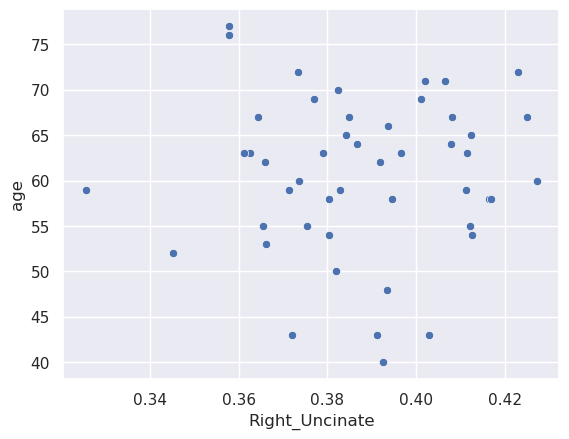

In [ ]:
# Exploratory plots

sns.scatterplot(x="Right_Uncinate", y="age", data=df_subj_FA)

## **Linear Regression (OLS)** 

Model:
$$y = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p + \varepsilon$$

- Ordinary Least Squares (OLS) estimates the coefficients by choosing values of $\beta$ that minimize the sum of squared residuals, $$\sum_i (y_i - \hat y_i)^2 $$
- Each coefficient represents the expected change in the response for a one-unit increase in that feature, holding other features constant. 

In [ ]:
model = smf.ols("age ~ Right_Uncinate", data=df_subj_FA)
model_fit = model.fit()

print(model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                    age   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                   0.01105
Date:                Mon, 20 Apr 2026   Prob (F-statistic):              0.917
Time:                        09:53:12   Log-Likelihood:                -170.87
No. Observations:                  48   AIC:                             345.7
Df Residuals:                      46   BIC:                             349.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         58.3136     22.225      2.

<Axes: xlabel='Right_Uncinate', ylabel='age'>

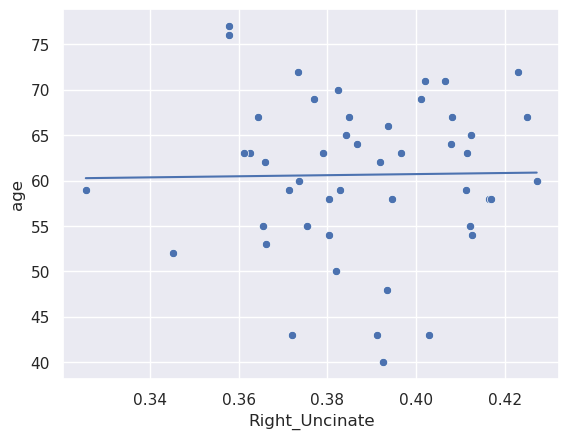

In [ ]:
sns.scatterplot(x="Right_Uncinate", y="age", data=df_subj_FA)
sns.lineplot(x=df_subj_FA["Right_Uncinate"], y=model_fit.fittedvalues)

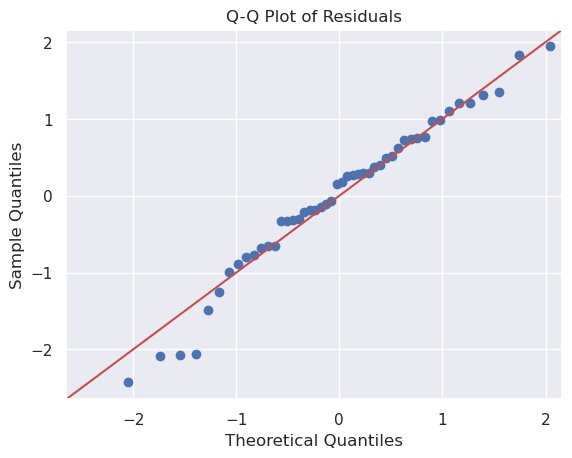

In [ ]:
sm.qqplot(model_fit.resid, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [ ]:
formula = "age ~ " + " + ".join(df_subj_FA.columns[8:])
model_fit = smf.ols(formula, data=df_subj_FA).fit()
print(model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                    age   R-squared:                       0.279
Model:                            OLS   Adj. R-squared:                 -0.256
Method:                 Least Squares   F-statistic:                    0.5211
Date:                Mon, 20 Apr 2026   Prob (F-statistic):              0.932
Time:                        09:53:12   Log-Likelihood:                -163.05
No. Observations:                  48   AIC:                             368.1
Df Residuals:                      27   BIC:                             407.4
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [ ]:
pd.DataFrame({"Coefficients": model_fit.params, "P-Values": model_fit.pvalues})

,Coefficients,P-Values
Intercept,56.778942,0.326168
Callosum_Forceps_Major,-9.933675,0.855822
Callosum_Forceps_Minor,-137.407466,0.108243
Left_Arcuate,57.578955,0.600996
Left_Cingulum_Cingulate,0.666382,0.992754
Left_Cingulum_Hippocampus,24.932281,0.751376
Left_Corticospinal,19.924921,0.865879
Left_IFOF,19.970168,0.826369
Left_ILF,-15.123114,0.884016
Left_SLF,57.303046,0.563397


## **Logistic Regression**

Model:
$$\log\!\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$$

where $p = P(y=1 \mid x)$, so equivalently
$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p)}}$$

- Logistic regression estimates the coefficients by maximizing the likelihood of the observed binary outcomes, equivalently minimizing the log-loss (cross-entropy):
$$-\sum_i \left[y_i \log(\hat p_i) + (1-y_i)\log(1-\hat p_i)\right]$$
- Each coefficient represents the change in the **log-odds** of the positive class for a one-unit increase in that feature, holding other features constant; equivalently, $e^{\beta_j}$ is the multiplicative change in the odds.

In [ ]:
df_subj_FA["class_binary"] = (df_subj_FA["class"] == "ALS").astype(int) # Outcome needs to be numeric binary for logistic regression

# Use smf.logit tyo fit a logistic regression model predicting disease status (class_binary) from the FA values of the tracts